### Understanding the limitations of RNNs and the need for attention
* Challenges of RNNs
    * Sequential Processing
    * Long term dependency problems
    * Fixed Context Vector
* The  Role of attention mechanisms
    * Attention overcomes these limitations by allowing the model to focus on specific parts fo the input sequence dynamically during each output generation step
    * Instead of reloying on a single contexct vector , attnetion provide a weightred combination of all input tokens relevant to the current output token
### Basics of the Attention mechanism
* Core Components
    * Queries (Q)
        * Represent the current focus of the model (eg, the current decoder state in Seq2Seq tasks)
    * Keys (K)
        * Encoded represntation of the input sequence
    * values (v)
        * Additional information associated witht the keys

* Attention Mechanism
    * the attentions score is computed using the dot priodyuct of the query and keys, followed by a s softtmax fucntion to nimalize into probabulity distribution
    * The weighted sum of the values forms the context vector

        Attention(Q,K,V)= softmax((QK^T)/root(d_k)).V

* Types of attention
    * Self attention
        * The query , key, and value all come from the same input sequence
        * widely used in transformer models for learning interdependencies within a sequence
    * Multi-Head Attention
        * Extends self-attention by applying multiple attention mecahinsme in parallel
        * captures different aspects fo relationships in the sequence
            * MultiHead(Q,K,V)= Concat(head_1,head_2,..., head_h) W^o
            * where heach head computes attention with different learned projections of Q,k and V
        


In [1]:
import numpy as np


In [3]:
# Define Queries , Keys and Values
queries = np.array([[1,0,1],[0,1,1]])

keys = np.array([[1,0,1],[1,1,0],[0,1,1,]])
values = np.array([[10,0],[0,10],[5,5]])



In [5]:
# compute attention scores
scores = np.dot(queries, keys.T)
# Apply softmax to normalize
def softmax (x):
    exp_x = np.exp(x-np.max(x, axis=-1,keepdims=True))
    return exp_x / exp_x.sum(axis=-1, keepdims=True)

attention_weights = softmax(scores)


In [6]:
# Compute weighted sum of values
context = np.dot(attention_weights,values)

print(f"Attention Weights: ", attention_weights)
print(f"Context vectors: ",context)

Attention Weights:  [[0.57611688 0.21194156 0.21194156]
 [0.21194156 0.21194156 0.57611688]]
Context vectors:  [[6.82087664 3.17912336]
 [5.         5.        ]]


In [7]:
import torch
import torch.nn.functional as F


In [10]:
# Define Queries , Keys and Values
queries = torch.tensor([[1.0,0.0,1.0],[0.0,1.0,1.0]])

keys = torch.tensor([[1.0,0.0,1.0],[1.0,1.0,0.0],[0.0,1.0,1.0,]])
values = torch.tensor([[10.0,0.0],[0.0,10.0],[5.0,5.0]])

In [11]:
# Compute attention scores
scores= torch.matmul(queries,keys.T)

# Apply Softmax to normalize scores
attention_weights = F.softmax(scores, dim=-1)

# Compute weighted sum of values
context = torch.matmul(attention_weights, values)

print(f"Attention Weights: ", attention_weights)
print(f"Context vectors: ",context)

Attention Weights:  tensor([[0.5761, 0.2119, 0.2119],
        [0.2119, 0.2119, 0.5761]])
Context vectors:  tensor([[6.8209, 3.1791],
        [5.0000, 5.0000]])


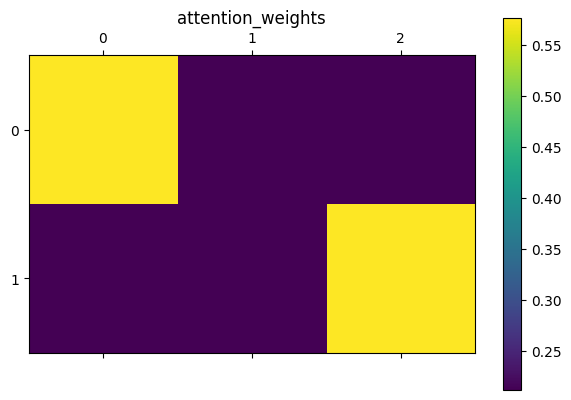

In [12]:
import matplotlib.pyplot as plt

# visualize attention weights

plt.matshow(attention_weights)
plt.colorbar()
plt.title("attention_weights")
plt.show()